# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

### Общая информация ###

Дата выдачи: 16.04.2026

Мягкий дедлайн: 30.04.2026 23:59

Жесткий дедлайн:  05.05.2026 23:59

### О задании

В процессе выполнения этого домашнего задания вы:

1. Попрактикуетесь использовать решающие деревья из `sklearn` для задачи классификации на простых двумерных датасетах, научитесь визуализировать разделяющие плоскости и распознавать переобучение.

2. Реализуете своё решающее дерево для задачи классификации и сравните его со стандартной имплементацией.

3. Исследуете влияние бэггинга на смещение и разброс.

### Оценивание и штрафы

Каждая из задач имеет определенную стоимость, которая указана в скобках около номера задачи. Максимально допустимая оценка за работу $-$ 10 баллов.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.


### Формат сдачи

Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Номера лучших посылок в [Яндекс.Контесте](https://new.contest.yandex.ru/contests/72204/start) для обеих задач

В [Яндекс.Контест](https://new.contest.yandex.ru/contests/72204/start) нужно отправить файл hw5code.py с реализованными функциями и классами.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__ 10

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Решающие деревья

### Визуализация (1 балл)

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [39]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

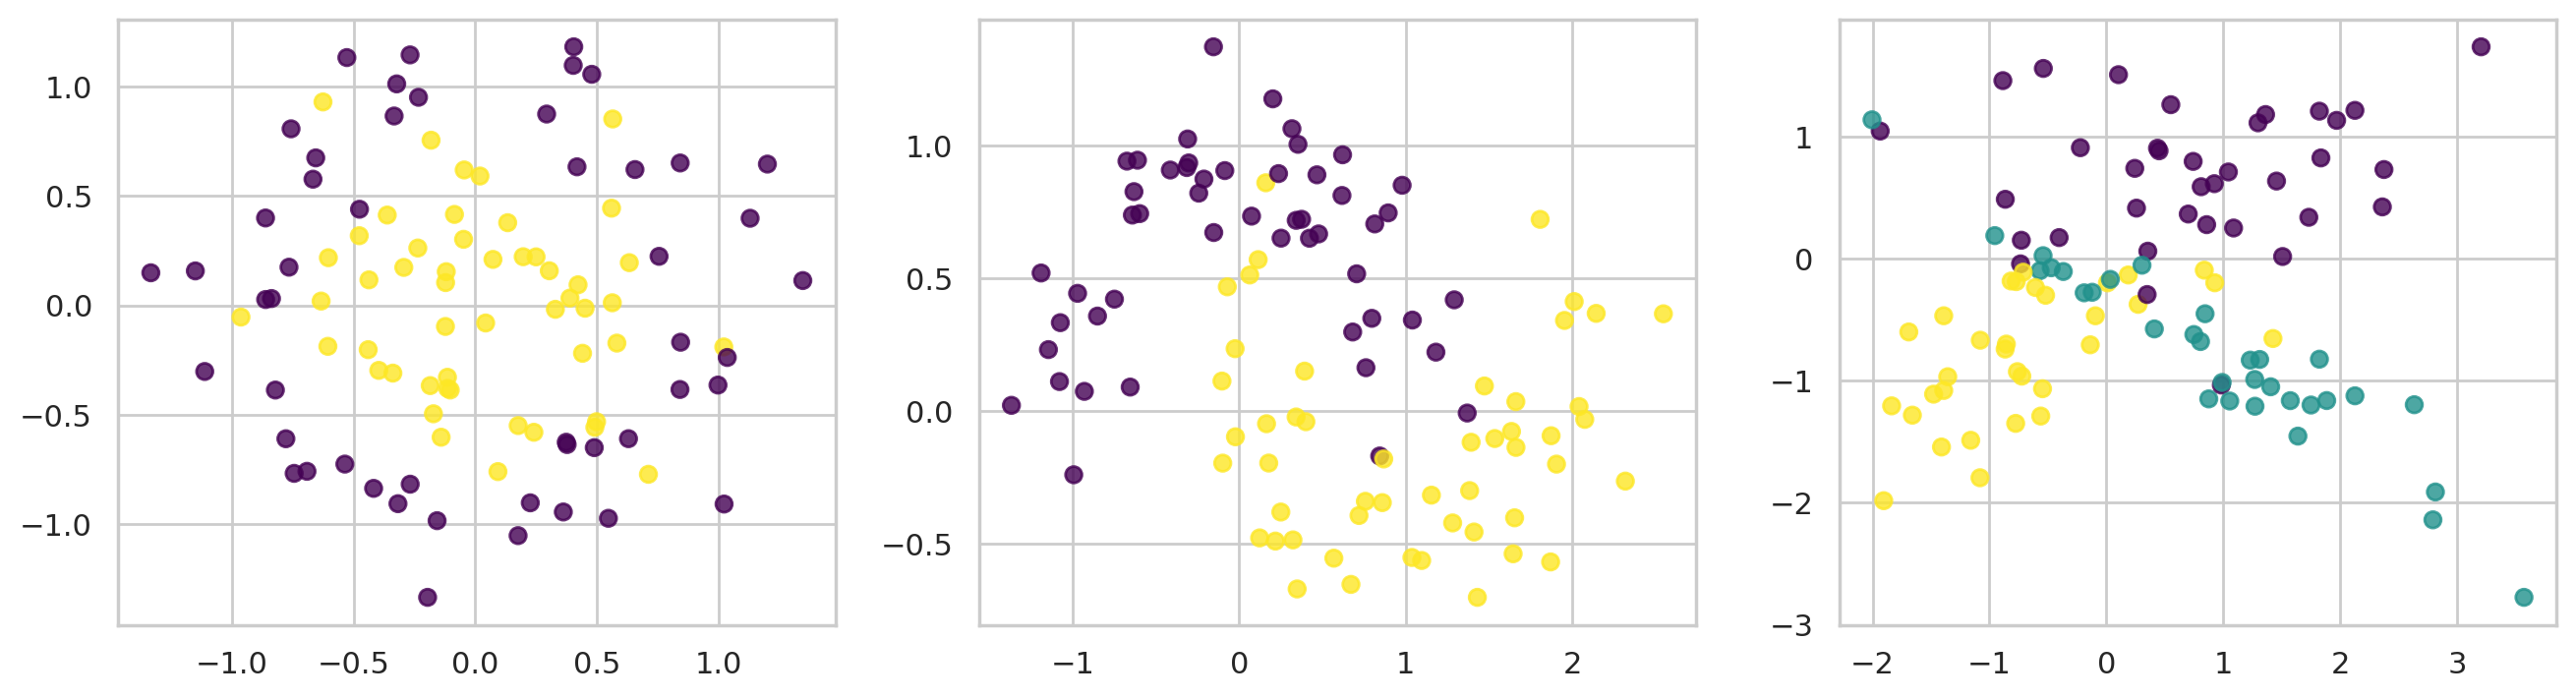

In [40]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

__Задание 1. (0.5 балла)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности и посчитайте accuracy на обучающей и тестовой выборках. Прокомментируйте, в каких случаях и почему модель переобучается.

In [41]:
# для красивой визуализации
%matplotlib inline

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

Circles
Train accuracy: 1.000
Test accuracy: 0.733

Moons
Train accuracy: 1.000
Test accuracy: 0.867

Classification
Train accuracy: 1.000
Test accuracy: 0.667



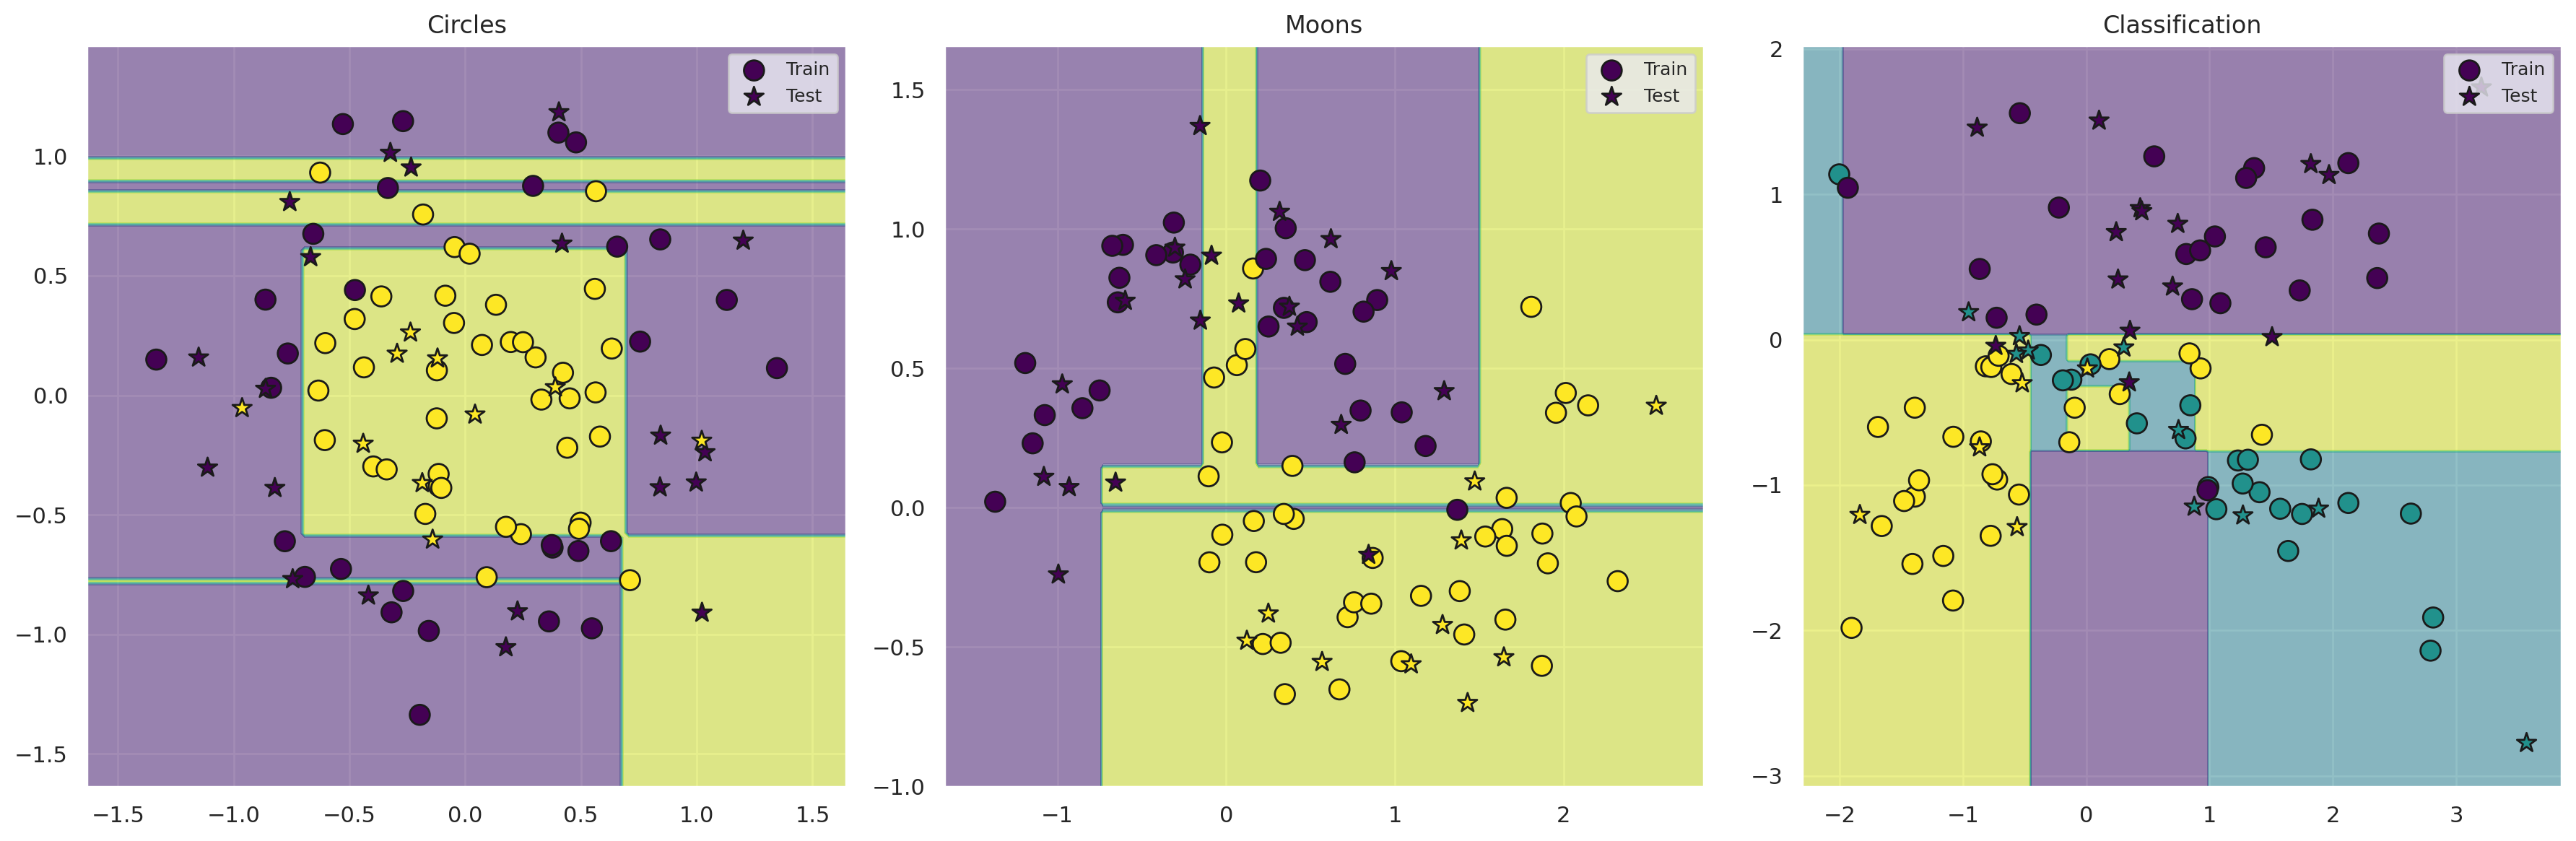

In [42]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.metrics import accuracy_score

names = ["Circles", "Moons", "Classification"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (X, y), name in zip(axes, datasets, names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc  = accuracy_score(y_test, tree.predict(X_test))
    print(f"{name}")
    print(f"Train accuracy: {train_acc:.3f}")
    print(f"Test accuracy: {test_acc:.3f}\n")

    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, z, alpha=0.5, cmap="viridis")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", edgecolor="k", marker='o', s=100, label="Train")
    ax.scatter(X_test[:, 0],  X_test[:, 1],  c=y_test,  cmap="viridis", edgecolor="k", marker="*", s=100, label="Test")
    ax.set_title(f"{name}", fontsize=12)
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

__Ответ:__ Во всех трёх случаях train accuracy = 1.000

`Circles`: Test accuracy = 0.733\
Истинная граница между классами — нелинейная форма. Дерево вынуждено аппроксимировать её множеством прямоугольных срезов (на графике видны эти полосы). Каждый такой прямоугольник подстраивается под конкретные шумовые точки обучающей выборки — отсюда плохой результат на тесте.

`Moons`: Test accuracy = 0.867\
Истинная граница тоже нелинейная, но геометрически проще, чем у Circles, поэтому достаточно нескольких горизонтальных и вертикальных разрезов для разделения. На графике видно, что основные зоны выделены относительно хорошо, хотя в некоторых местах дерево все же подстраивалось под шум.

`Classification`: Test accuracy = 0.667 (самое сильное переобучение)\
Разрыв train–test здесь наибольший(0.333). На графике видно, что классы сильно перекрываются в центральной области, там много точек разных классов рядом. Дерево без ограничений глубины создаёт очень маленькие «островки» для каждой такой точки, что на тесте даёт плохую генерализацию.

__Задание 2. (0.5 балла)__

Выберите один датасет из предыдущего задания и исследуйте на его примере влияние на итоговое качество двух гиперпараметров (любых на ваш выбор) одновременно. Для каждой пары значений посчитайте accuracy на обучающей и тестовой выборках и сохраните результаты в таблицу.

Визуализируйте зависимость качества на тестовой выборке от значений выбранных вами гиперпараметров. При каких значениях наблюдается лучшее соотношение разброса и смещения? Почему вы сделали такой вывод?

 max_depth  min_impurity_decrease  train_accuracy  test_accuracy  accuracy_diff
     2.000                  0.000           0.829          0.633          0.195
     2.000                  0.010           0.829          0.633          0.195
     2.000                  0.020           0.829          0.633          0.195
     2.000                  0.030           0.814          0.667          0.148
     2.000                  0.050           0.814          0.667          0.148
     3.000                  0.000           0.886          0.733          0.152
     3.000                  0.010           0.886          0.733          0.152
     3.000                  0.020           0.886          0.733          0.152
     3.000                  0.030           0.871          0.767          0.105
     3.000                  0.050           0.871          0.767          0.105
     4.000                  0.000           0.957          0.733          0.224
     4.000                  0.010       

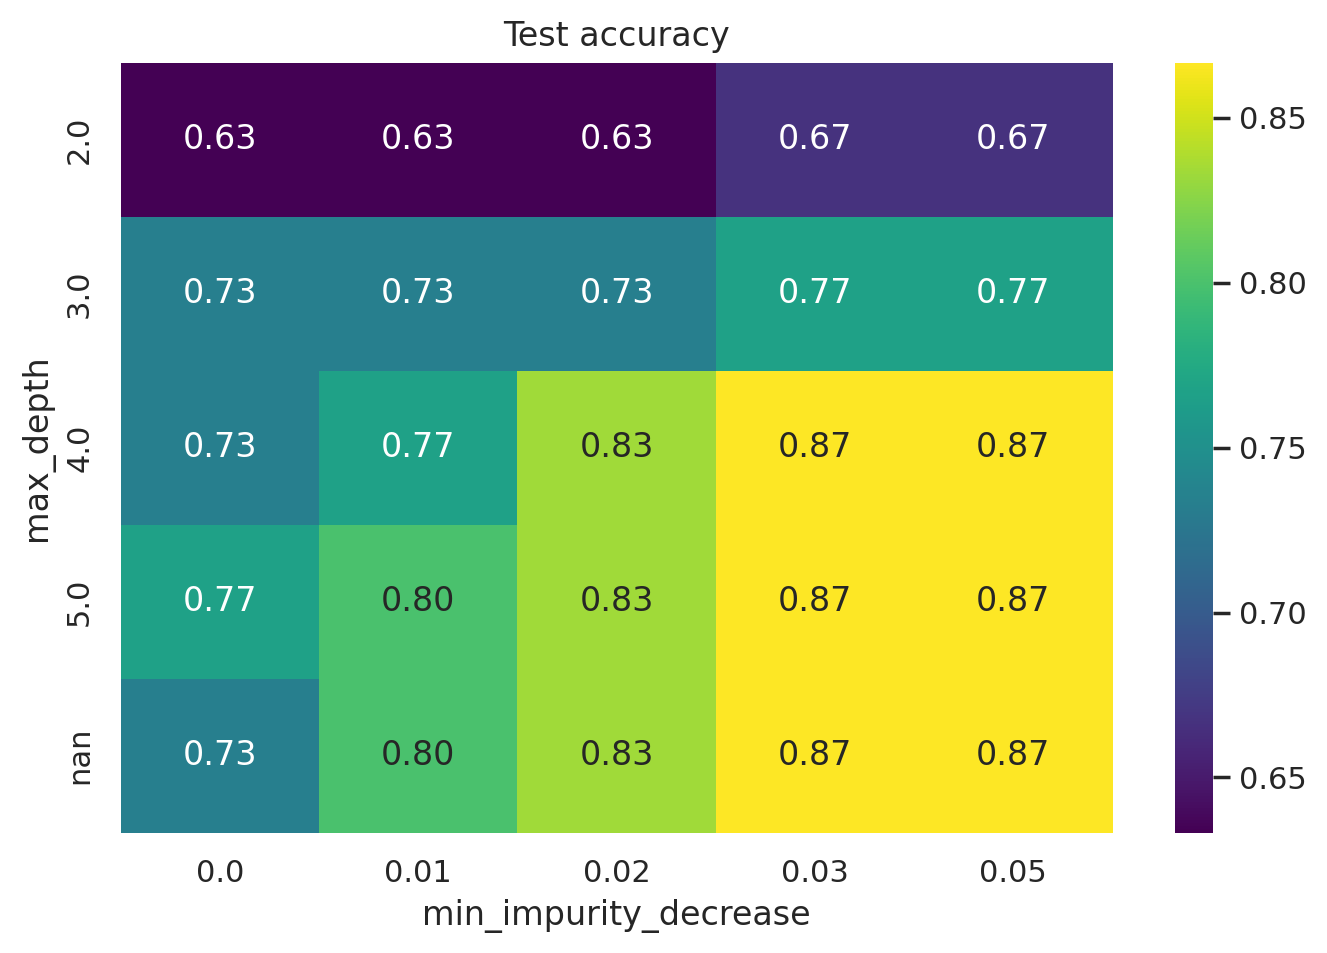

Первая лучшая пара: max_depth=4.0, min_impurity_decrease=0.03, test_accuracy=0.867


In [43]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
X, y = make_circles(noise=0.2, factor=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

results = []
for depth in [2, 3, 4, 5, None]:
    for impurity in [0, 0.01, 0.02, 0.03, 0.05]:
        tree = DecisionTreeClassifier(max_depth=depth,
                                     min_impurity_decrease=impurity,
                                     random_state=42)
        tree.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, tree.predict(X_train))
        test_acc = accuracy_score(y_test, tree.predict(X_test))
        results.append({
            'max_depth': depth,
            'min_impurity_decrease': impurity,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'accuracy_diff': train_acc - test_acc
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False, float_format='%.3f'))

pivot = df_results.pivot(index='max_depth', columns='min_impurity_decrease',values='test_accuracy')
pivot = pivot.sort_index()
pivot = pivot.sort_index(axis=1)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("Test accuracy")
plt.show()

best = df_results.loc[df_results['test_accuracy'].idxmax()]
print(f"Первая лучшая пара: max_depth={best.max_depth}, "
      f"min_impurity_decrease={best.min_impurity_decrease}, "
      f"test_accuracy={best.test_accuracy:.3f}")

__Ответ:__\
При маленьких значениях max_depth - недообучение\
Дерево слишком простое, не может аппроксимировать нелинейные границы, не улавливает сложную структуру данных. Поэтому качество низкое как на обучающей, так и на тестовой выборке.

При средних значениях max_depth($\approx$4) и impurity($\approx$0.03) - оптимум\
Достигается баланс между сложностью модели и её обобщающей способностью. Дерево достаточно глубокое, чтобы уловить форму границ, при этом есть регуляризация, чтобы не подстраиваться под шум. Test accuracy максимальный(0.867), разрыв train-test минимальный.

При большой глубине дерева или слишком малом impurity - переобучение\
 Модель становится сложной. Дерево запоминает шум, а не закономерность. Train accuracy стремится к 1, а  test accuracy не улучшается или даже ухудшается.

### Решающие деревья своими руками (6 баллов)

Итак, пришло время реализовать свой класс для обучения решающего дерева.

__Задание 3. (1.5 балла)__

Реализуйте функцию `find_best_split` из модуля `hw5code.py` согласно алгоритму, расказанному на лекции; её сигнатура и докстринг с дополнительными требованиями и указаниями прописаны в файле.

Напоминаем, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R, R_l, R_r) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности Джини для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.


__Задание 4. (0.75 балл)__

Загрузите датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Поработайте с данными: создайте бинарный признак `pass`, который будет равен единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выберите пять числовых признаков, среди которых должны быть как очень информативные, так и потенциально неинформативные. Коротко обоснуйте свой выбор.

Для каждого из выбранных признаков постройте график зависимости критерия Джини от возможного порога разделения. Отобразите все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализируйте зависимость
"значение признака - класс (0/1)".

> Можно, например, построить scatter-график, где по оси X - значение признака, а по оси Y - бинарный признак `pass` (при необходимости используйте небольшой jitter по оси Y и/или прозрачность alpha, чтобы лучше видеть плотность точек); или использовать эквивалентную по смыслу визуализацию (например, `seaborn.stripplot` / `swarmplot`), из которой видно, как распределены значения признака внутри каждого класса.

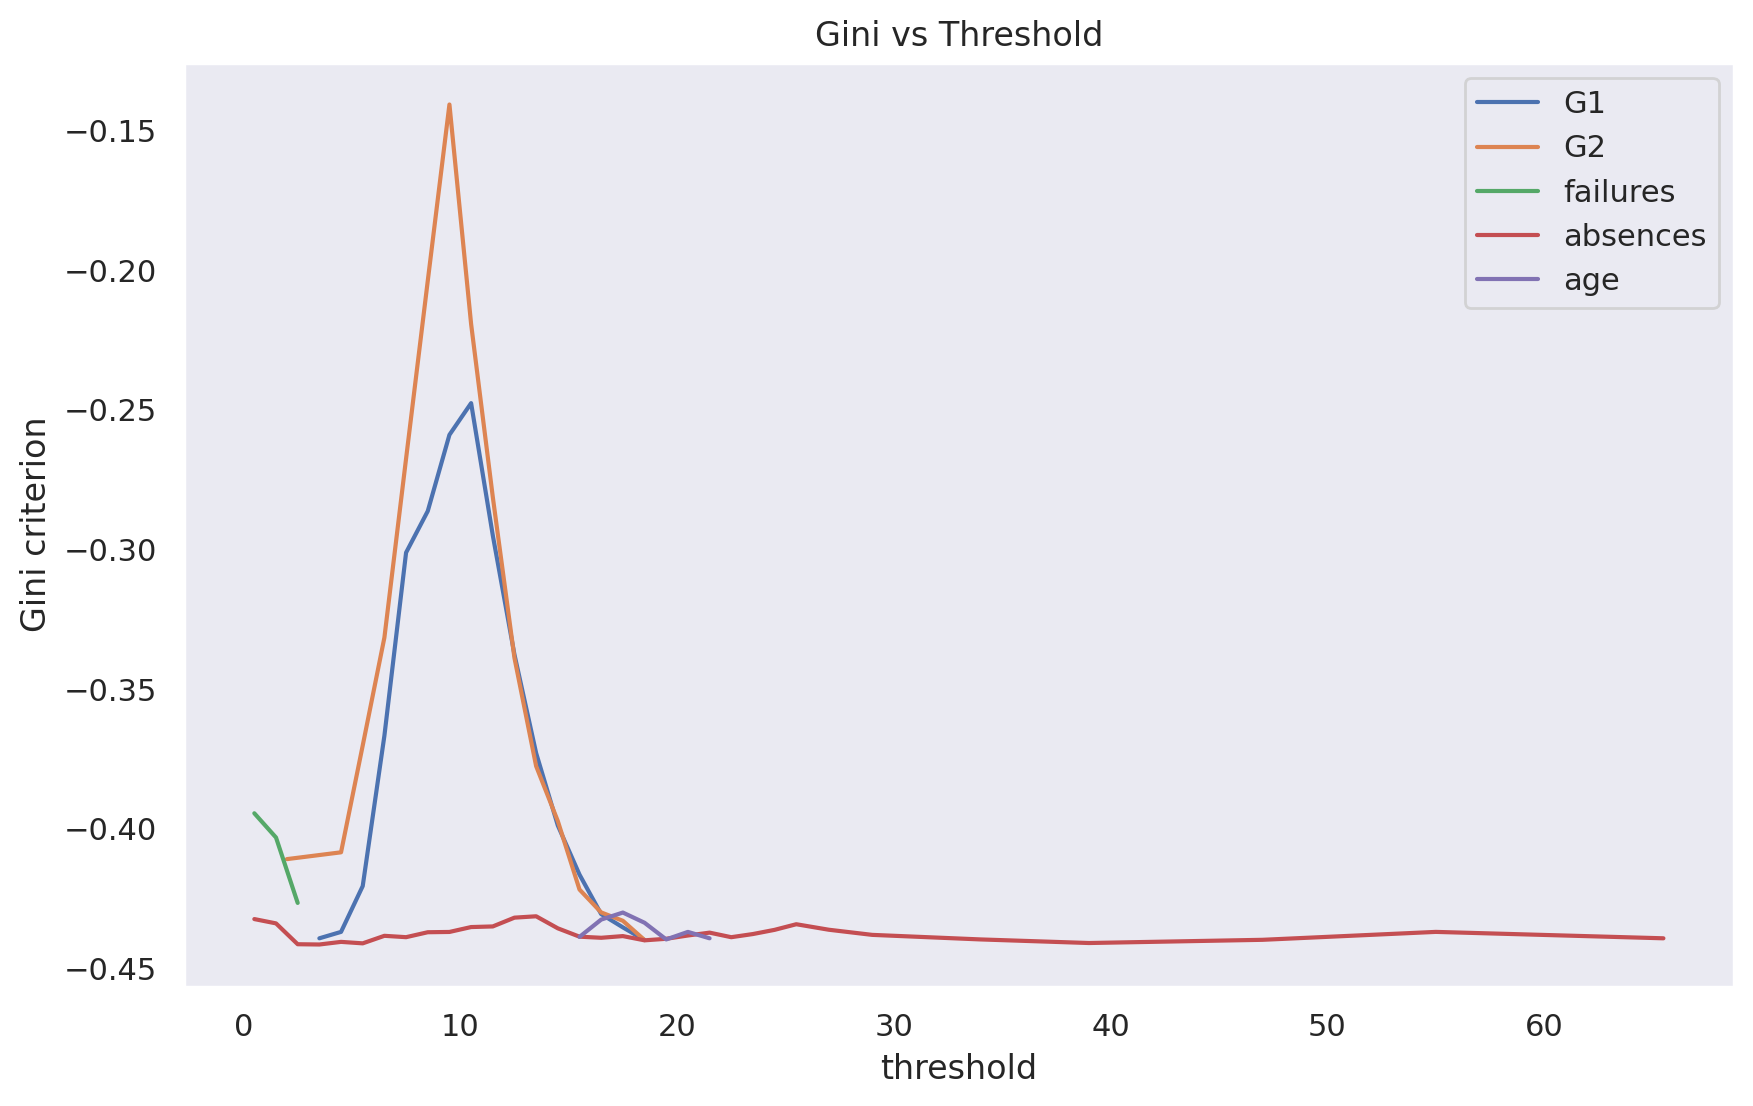

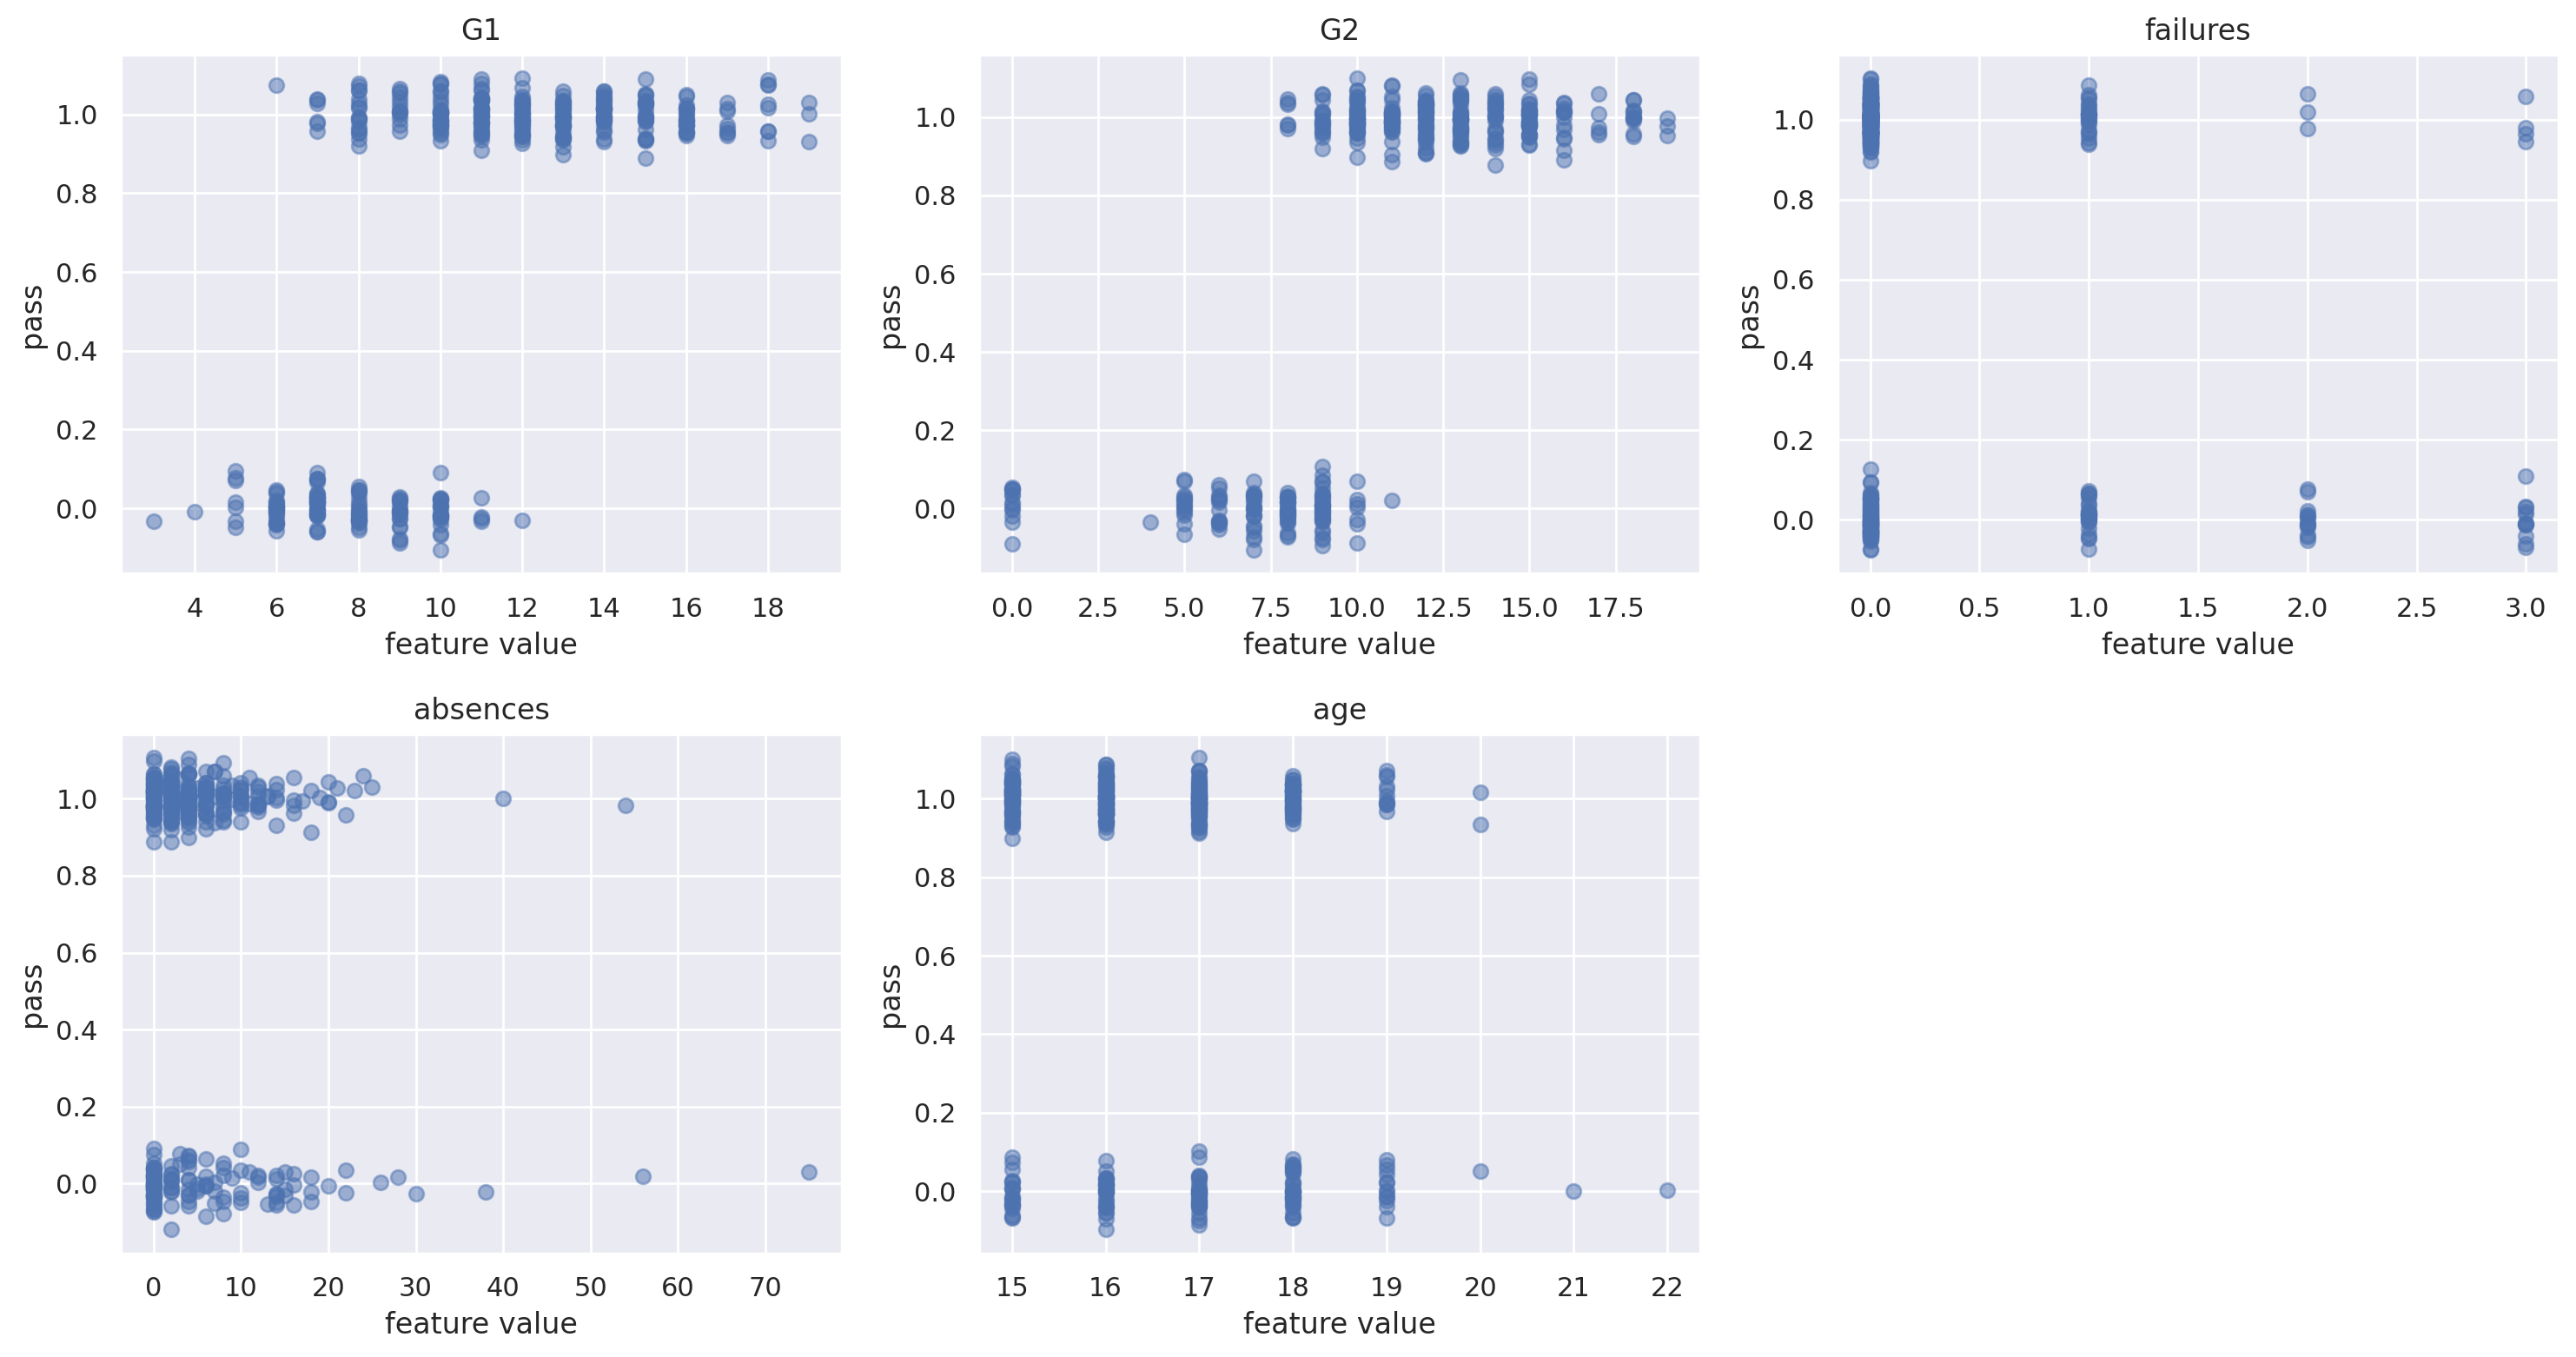

In [44]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from hw5code import find_best_split
df = pd.read_csv("student-mat.csv", sep=";")
df["pass"] = (df["G3"] >= 10).astype(int)
features = ["G1", "G2", "failures", "absences", "age"]
plt.figure(figsize=(10, 6))
for feature in features:
    x = df[feature].values
    y = df["pass"].values
    thresholds, ginis, _, _ = find_best_split(x, y)
    if len(thresholds) > 0:
        plt.plot(thresholds, ginis, label=feature)
plt.xlabel("threshold")
plt.ylabel("Gini criterion")
plt.title("Gini vs Threshold")
plt.legend()
plt.grid()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feature in enumerate(features):
    x = df[feature].values
    y = df["pass"].values
    jitter = np.random.normal(0, 0.04, size=len(y))
    axes[i].scatter(x, y + jitter, alpha=0.5)
    axes[i].set_title(feature)
    axes[i].set_xlabel("feature value")
    axes[i].set_ylabel("pass")
axes[5].axis('off')
plt.tight_layout()
plt.show()

__Ответ:__\
Обоснование выбора признаков:\
`G1`, `G2` (оценки за 1-й и 2-й период) — очень информативные\
Итоговая оценка G3 сильно коррелирует с промежуточными: студент, получивший хорошую оценку в первом или втором периоде, почти наверняка хорошо сдаст финальный экзамен. Это подтверждается графиками.

`failures`(прошлые неудачи) — умеренно информативный\
Студенты, имеющие много неудач, имеют более низкий шанс успешно сдать экзамен. По графику видно, что чем больше значение failures, тем меньше успешно сдающих. Однако стоит отметить, что число провалившихся на экзамене также уменьшается с увеличением значения failures.

`absences`(количество пропусков) — умеренно информативный\
Частые прогулы должны коррелировать с провалом, что в целом прослеживается из графика: чем больше absences, тем меньше количество сдавших. Однако распределение значений самого признака неравномерно: в данных большинство студентов имеют значение absences близкое к 0, поэтому количество несдавших тоже уменьшается с увеличением absences $\Rightarrow$ сложно сделать однозначный вывод про зависимость.

`age`(возраст) - неинформативный\
Возраст слабо предсказывает успех. Диапазон небольшой: 15–22, большинство — 15–17. По графику видно, что количество сдаших для каждого значения age практически одинаково, то же самое можно сказать и про количество несдавших.

__Задание 5. (0.25 балла)__

На основании построенных в прошлом задании графиков ответьте на следующие вопросы:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

**Ответ:**
1. Лучший признак для разделения — G2, так как он дает максимальный прирост критерия Джини(threshold $\approx$ 10, Gini criterion $\approx$ -0.15). Для этого признака на графике критерия Джини наблюдается наиболее выраженный максимум, значение критерия Джини(по модулю) наиболее оптимальное среди всех признаков.

2. Это полностью согласуется с анализом Scatter-графиков. Они показывают, что по признаку G2 можно провести вертикальную линию(порог $\approx$ 10), которая хорошо разделяет классы, а по другим признакам(кроме G2 и G1) такой линии провести невозможно.

3. Идеально разделяющий признак даёт чётко выраженный пик на кривой Джини, а бесполезные признаки — горизонтальную линию на одном уровне, значения критерия Джини для них меняются незначительно.

__Задание 6. (1.5 балла)__

Разберитесь с уже написанным кодом в классе `DecisionTree` модуля `hw5code.py`. Исправьте ошибки в методе `_fit_node`, а также реализуйте `_predict_node`.

В данном задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения необходимо производить по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (можете найти его в конспекте в разделе «Учёт категориальных признаков»)

__Задание 7. (0.5 балла)__

Протестируйте написанное вами решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого необходимо скачать таблицу agaricus-lepiota.data и применить к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в рассматриваемой таблице $-$ это целевая переменная ('e' $-$ edible, 'p' $-$ poisonous).

Обучите решающее дерево на $50\%$ случайно выбранных объектов и получите предсказания для оставшейся половины. Вычислите accuracy. Если в предыдущих заданиях вы всё сделали корректно, то у вас должно получиться качество очень близкое единице или даже равное ей.

In [45]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.preprocessing import LabelEncoder
from hw5code import DecisionTree
df = pd.read_csv("agaricus-lepiota.data", header=None)
le = LabelEncoder()
df_encoded = df.apply(lambda col: le.fit_transform(col.astype(str)))
X = df_encoded.iloc[:, 1:].values
y = df_encoded.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)
feature_types = ["categorical"] * X.shape[1]
tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Train accuracy: 1.000
Test accuracy: 1.000


__Задание 8. (1 балл)__

Реализуйте в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `sklearn.tree.DecisionTreeClassifier`.

__Задание 9. (0.5 балла)__

Проверьте, спасают эти параметры вас от переобучения.

Для этого **решите при помощи собственной имплементации `DecisionTree`  задачу классификации цвета вина** (color) по его химическим характеристикам на датасете [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Как обычно, случайно разбейте свой датасет на тест-трейн (в отношении 7:3), и далее сравните на них поведение двух деревьев:
- Для первого дерева не используйте параметры из задания 8
- Для второго дерева выберите разумные значения этих параметров (в этом конкретном случае мы рекомендуем `max_depth=8, min_samples_leaf=5, min_samples_split=17`), и постройте дерево с их использованием.
  - Подбирать оптимальные параметры здесь не требуется

Выведите метрики качества классификации. **Что вы наблюдаете, и почему так произошло?**


В качестве sanity check сравните качество работы и структуру вашего второго дерева с результатом стандартной имплементации из `sklearn`. Не забудьте подать ему на вход те же параметры.

**Обратите внимание, что в оригинале таргетом является качество вина; мы же с вами предсказываем его цвет.** В каком-то смысле, это модель-сомелье.


*Андер-сэмплирование данных далее сделано специально, чтобы продемонстрировать должный эффект. Убирать его запрещается.*

In [46]:
%pip install ucimlrepo

In [47]:
from ucimlrepo import fetch_ucirepo

np.random.seed(0)

wine_quality = fetch_ucirepo(id=186)


In [48]:

df = wine_quality.data.original.sample(frac=0.1)

X = df.drop(columns=['color'])
y = df['color']


In [49]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 650 entries, 5316 to 5545
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         650 non-null    float64
 1   volatile_acidity      650 non-null    float64
 2   citric_acid           650 non-null    float64
 3   residual_sugar        650 non-null    float64
 4   chlorides             650 non-null    float64
 5   free_sulfur_dioxide   650 non-null    float64
 6   total_sulfur_dioxide  650 non-null    float64
 7   density               650 non-null    float64
 8   pH                    650 non-null    float64
 9   sulphates             650 non-null    float64
 10  alcohol               650 non-null    float64
 11  quality               650 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 66.0 KB


In [50]:
y.info()

<class 'pandas.core.series.Series'>
Index: 650 entries, 5316 to 5545
Series name: color
Non-Null Count  Dtype 
--------------  ----- 
650 non-null    object
dtypes: object(1)
memory usage: 10.2+ KB


In [51]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_values = X.values.astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X_values, y_encoded, test_size=0.3, random_state=42
)
feature_types = ["real"] * X_values.shape[1]

tree_unreg = DecisionTree(feature_types=feature_types)
tree_unreg.fit(X_train, y_train)
train_pred_unreg = tree_unreg.predict(X_train)
test_pred_unreg = tree_unreg.predict(X_test)
train_acc_unreg = accuracy_score(y_train, train_pred_unreg)
test_acc_unreg = accuracy_score(y_test, test_pred_unreg)
print("Дерево без параметров")
print(f"Train accuracy: {train_acc_unreg:.4f}")
print(f"Test accuracy: {test_acc_unreg:.4f}\n")

tree_reg = DecisionTree(
    feature_types=feature_types,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17
)
tree_reg.fit(X_train, y_train)
train_pred_reg = tree_reg.predict(X_train)
test_pred_reg = tree_reg.predict(X_test)
train_acc_reg = accuracy_score(y_train, train_pred_reg)
test_acc_reg = accuracy_score(y_test, test_pred_reg)
print("Дерево с параметрами")
print(f"Train accuracy: {train_acc_reg:.4f}")
print(f"Test accuracy: {test_acc_reg:.4f}\n")

sklearn_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17,
    random_state=42
)
sklearn_tree.fit(X_train, y_train)
train_pred_sk = sklearn_tree.predict(X_train)
test_pred_sk = sklearn_tree.predict(X_test)
train_acc_sk = accuracy_score(y_train, train_pred_sk)
test_acc_sk = accuracy_score(y_test, test_pred_sk)
print("Sklearn DecisionTreeClassifier")
print(f"Train accuracy: {train_acc_sk:.4f}")
print(f"Test accuracy: {test_acc_sk:.4f}")

Дерево без параметров
Train accuracy: 1.0000
Test accuracy: 0.9436

Дерево с параметрами
Train accuracy: 0.9912
Test accuracy: 0.9538

Sklearn DecisionTreeClassifier
Train accuracy: 0.9912
Test accuracy: 0.9538


In [52]:
from sklearn.metrics import classification_report

print("Дерево без параметров")
print(classification_report(y_test, test_pred_unreg,target_names=le.classes_))
print("Дерево с параметрами")
print(classification_report(y_test, test_pred_reg, target_names=le.classes_))
print("Sklearn DecisionTreeClassifier")
print(classification_report(y_test, test_pred_sk, target_names=le.classes_))

Дерево без параметров
              precision    recall  f1-score   support

         red       0.86      0.94      0.90        52
       white       0.98      0.94      0.96       143

    accuracy                           0.94       195
   macro avg       0.92      0.94      0.93       195
weighted avg       0.95      0.94      0.94       195

Дерево с параметрами
              precision    recall  f1-score   support

         red       0.89      0.94      0.92        52
       white       0.98      0.96      0.97       143

    accuracy                           0.95       195
   macro avg       0.93      0.95      0.94       195
weighted avg       0.96      0.95      0.95       195

Sklearn DecisionTreeClassifier
              precision    recall  f1-score   support

         red       0.89      0.94      0.92        52
       white       0.98      0.96      0.97       143

    accuracy                           0.95       195
   macro avg       0.93      0.95      0.94       195


**Вывод:**\
`Дерево без параметров(без ограничений)` - переобучение.\
На обучающей выборке accuracy = 1, потому что дерево запомнило каждый объект. На тесте точность ниже. В этом случае  разница в точности на train и test особенно сильная, потому что дерево строит очень глубокие ветки под каждый шум в обучающей выборке.

`Дерево с параметрами(max_depth=8, min_samples_leaf=5, min_samples_split=17)` - разрыв между train и test сокращается, улучшается обобщающая способность.\
max_depth=8 не даёт дереву углубляться бесконечно - срезает нижние "шумовые" ветки\
min_samples_leaf=5 гарантирует, что в каждом листе будет хотя бы 5 объектов - более надёжный результат\
min_samples_split=17 запрещает разбивать узел, если в нём меньше 17 объектов - не допускает дроблению на маленькие части

`Sklearn DecisionTreeClassifier`- результаты очень близки к дереву c параметрами.

## Bias-variance decomposition (3 балла)

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [53]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

Во всех заданиях этого раздела (задания 10-11) используйте одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволит передавать их в общие функции.


### Вычисление bias и variance (1.5 балл)

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [54]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(33.67421339200312)

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__Задание 10.1 (1 балл)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [55]:
def compute_biase_variance(model, X, y, num_runs=1000):

    """
    :param model: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    n = len(y)
    predictions = [[] for _ in range(n)]

    for _ in range(num_runs):
        bootstrap_idx = np.random.randint(0, n, size=n)
        oob_mask = np.ones(n, dtype=bool)
        oob_mask[bootstrap_idx] = False
        oob_idx = np.where(oob_mask)[0]
        if len(oob_idx) == 0:
            continue
        model.fit(X[bootstrap_idx], y[bootstrap_idx])
        oob_preds = model.predict(X[oob_idx])
        for idx, pred in zip(oob_idx, oob_preds):
            predictions[idx].append(pred)

    bias_list = []
    variance_list = []
    error_list = []

    for i in range(n):
        preds = predictions[i]
        if len(preds) == 0:
            continue
        preds = np.array(preds)
        bias_i = (preds.mean() - y[i]) ** 2
        variance_i = preds.var()
        error_i = ((preds - y[i]) ** 2).mean()
        bias_list.append(bias_i)
        variance_list.append(variance_i)
        error_list.append(error_i)

    bias = np.mean(bias_list)
    variance = np.mean(variance_list)
    error = np.mean(error_list)

    return bias, variance, error

__Задание 10.2 (0.25 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что обсуждались на занятиях?

In [56]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

california = fetch_california_housing()
X = california["data"]
y = california["target"]
np.random.seed(42)
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
}
results = {}
for name, model in models.items():
    bias, var, err = compute_biase_variance(model, X, y, num_runs=30)
    results[name] = {"bias": bias, "variance": var, "error": err, "bias+var": bias + var}

df_results = pd.DataFrame(results).T.round(4)
df_results.index.name = "Модель"
print(df_results.to_string())

                         bias  variance   error  bias+var
Модель                                                   
LinearRegression       0.5502    0.1522  0.7024    0.7024
DecisionTreeRegressor  0.2738    0.2724  0.5461    0.5461
RandomForestRegressor  0.2484    0.0167  0.2651    0.2651


**Ответ:** Во всех трёх случаях bias + variance = error с точностью до четырёх знаков. Это подтверждает, что реализация согласуется с теорией.

`LinearRegression` - высокое смещение (0.55), низкий разброс (0.15) - недообучение\
Линейная модель предполагает, что цена жилья линейно зависит от признаков, но реальная зависимость нелинейна. Из-за этого модель систематически ошибается. Зато разброс невелик: предсказания стабильны.

`DecisionTreeRegressor` - низкое смещение (0.27), высокий разброс (0.27) - переобучение\
Дерево без ограничений глубины сильно подстраивается под обучающую выборку, поэтому смещение мало. Однако дерево чувствительно к шуму в данных. При малейшем изменении данных структура дерева кардинально меняется — отсюда высокий разброс.

`RandomForestRegressor` - низкое смещение (0.25), очень низкий разброс (0.017) - оптимум\
Лес усредняет предсказания многих деревьев, каждое из которых обучено на своей подвыборке со случайным подмножеством признаков. Смещение остаётся таким же низким, как у одного дерева, а разброс падает в несколько раз по сравнению с одним деревом - это и предсказывает теория. Итоговая ошибка 0.2651 - почти в 3 раза меньше, чем у линейной регрессии, и в 2 раза меньше, чем у одного дерева.

__Задание 10.3 (0.25 баллов)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

In [57]:
from sklearn.ensemble import BaggingRegressor

california = fetch_california_housing()
X = california["data"]
y = california["target"]
np.random.seed(42)
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42, n_estimators=10),
}
results = {}
for name, model in models.items():
    bagging_model = BaggingRegressor(
        estimator=model,
        n_estimators=10,
        random_state=42
    )
    bias_b, var_b, err_b = compute_biase_variance(bagging_model, X, y, num_runs=30)
    results[f"Bagging({name})"] = {
        "bias": bias_b, "variance": var_b, "error": err_b, "bias+var": bias_b + var_b
    }

df = pd.DataFrame(results).T.round(4)
df.index.name = "Модель"
print(df.to_string())

                                  bias  variance   error  bias+var
Модель                                                            
Bagging(LinearRegression)       0.6363    0.1994  0.8357    0.8357
Bagging(DecisionTreeRegressor)  0.2515    0.0413  0.2929    0.2929
Bagging(RandomForestRegressor)  0.2569    0.0119  0.2688    0.2688


**Ответ:** Теория: бэггинг из m независимых моделей уменьшает разброс в m раз. При n_estimators=10 ожидается уменьшение variance в 10 раз.

`LinearRegression` - variance вырос\
Линейная регрессия стабильна - её разброс и так мал (0.1522). Бутстрап-выборки дают немного разные обучающие множества, и каждая модель в бэггинге получает смещённые оценки коэффициентов (из-за выбора с возвращением часть объектов повторяется, часть выпадает). В результате усреднение нескольких немного смещённых моделей увеличивает и смещение, и ошибку. Бэггинг не предназначен для стабильных алгоритмов.

`DecisionTree` - 6.6x вместо 10x - ближайший к теории результат\
Теоретический предел достигается только при полностью независимых базовых моделях. В бэггинге все деревья обучаются на бутстрап-выборках из одних и тех же данных - они видят похожие паттерны и коррелируют между собой. Уменьшение variance в 10 раз получилось бы, если бы алгоритмы выдавали слабо коррелированные ответы.

`RandomFores` - 1.4x - средний результат\
Лес сам по себе уже является бэггингом с рандомизацией признаков - разброс внутри уже снижен. Бэггинг над лесом - это «бэггинг над бэггингом»: все 10 базовых лесов дают очень похожие предсказания (высокая корреляция), поэтому variance практически не снижается после бэггинга над лесом.

### Визуализация предсказаний базовых алгоритмов бэггинга (1.5 балл)

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

__Задание 11.1 (1 балл)__

Реализуйте функцию `plot_predictions`, которая должна выполнять следующие шаги:

1. Выбор подмножества данных. Случайным образом выберите num_test_objects пар "объект-целевая переменная" из исходных данных X, y. Выбранные объекты образуют тестовую выборку X_test, y_test, остальные - обучающую выборку X_train, y_train.

2. Метод бутстрапа. Сгенерируйте методом бутстрапа num_runs новых выборок из X_train, y_train. На каждой такой выборке обучите алгоритм и сделайте предсказания для объектов X_test.

3. Построение графика. Нарисуйте scatter-график, где по оси абсцисс - номера тестовых объектов от 0 до num_test_objects - 1 (а не сами значения признаков); по оси ординат - предсказания моделей на этих объектах. В итоге должно получиться num_test_objects вертикальных столбиков из точек: для каждого тестового объекта его num_runs предсказаний.

   Для каждого тестового объекта:
   * отметьте все предсказания для него одним цветом (чтобы был виден столбик);
   * истинный ответ y_test для этого объекта отметьте чёрной точкой.

Не забудьте подписать оси, а также добавить заголовок графика.

> *Примечание.* Раскраска предсказаний по тестовым объектам нужна только для удобства: так легче визуально отличать столбики друг от друга. Можно также сделать все предсказания одного цвета, а истинные значения - чёрными.
>
> Если хотите более явно увидеть bias–variance, можно дополнительно построить второй график, где по оси X - номера тестовых объектов, а по оси Y - разница `mean_pred(x_i) − y_i` (оценка bias), и, например, показать разброс предсказаний в виде вертикальных отрезков или доверительных интервалов.
>
> При больших значениях num_runs вместо (или вместе с) отдельных точек допустимо использовать boxplot/violinplot.


In [58]:
from sklearn.base import clone


def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title="", ax=None):
    """
    plot graphics described above
    """

    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    n = len(y)
    test_idx = np.random.choice(n, size=num_test_objects, replace=False)
    train_mask = np.ones(n, dtype=bool)
    train_mask[test_idx] = False
    X_test, y_test = X[test_idx], y[test_idx]
    X_train, y_train = X[train_mask], y[train_mask]
    n_train = len(y_train)
    all_preds = np.zeros((num_runs, num_test_objects))
    for run in range(num_runs):
        boot_idx = np.random.randint(0, n_train, size=n_train)
        m = clone(model)
        m.fit(X_train[boot_idx], y_train[boot_idx])
        all_preds[run] = m.predict(X_test)

    xs = np.arange(num_test_objects)
    mean_preds = all_preds.mean(axis=0)
    std_preds = all_preds.std(axis=0)
    colors = plt.cm.tab10(np.linspace(0, 1, num_test_objects))
    for obj in range(num_test_objects):
        jitter = np.random.uniform(-0.15, 0.15, size=num_runs)
        ax.scatter(xs[obj] + jitter, all_preds[:, obj], color=colors[obj], alpha=0.3, s=15, zorder=1)
    ax.scatter(xs, y_test, color="black", marker="o", s=80, zorder=5, label="истинное значение")
    bias = np.mean((mean_preds - y_test) ** 2)
    variance = np.mean(std_preds ** 2)
    ax.set_xticks(xs)
    ax.set_xlabel("Номер тестового объекта", fontsize=10)
    ax.set_ylabel("Предсказание", fontsize=10)
    ax.set_title(f"{title}\n" f"bias={bias:.3f}, variance={variance:.3f}", fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

__Задание 11.2 (0.5 балла)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат. Это поможет корректно проанализировать масштаб разброса у каждого из этих алгоритмов.

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

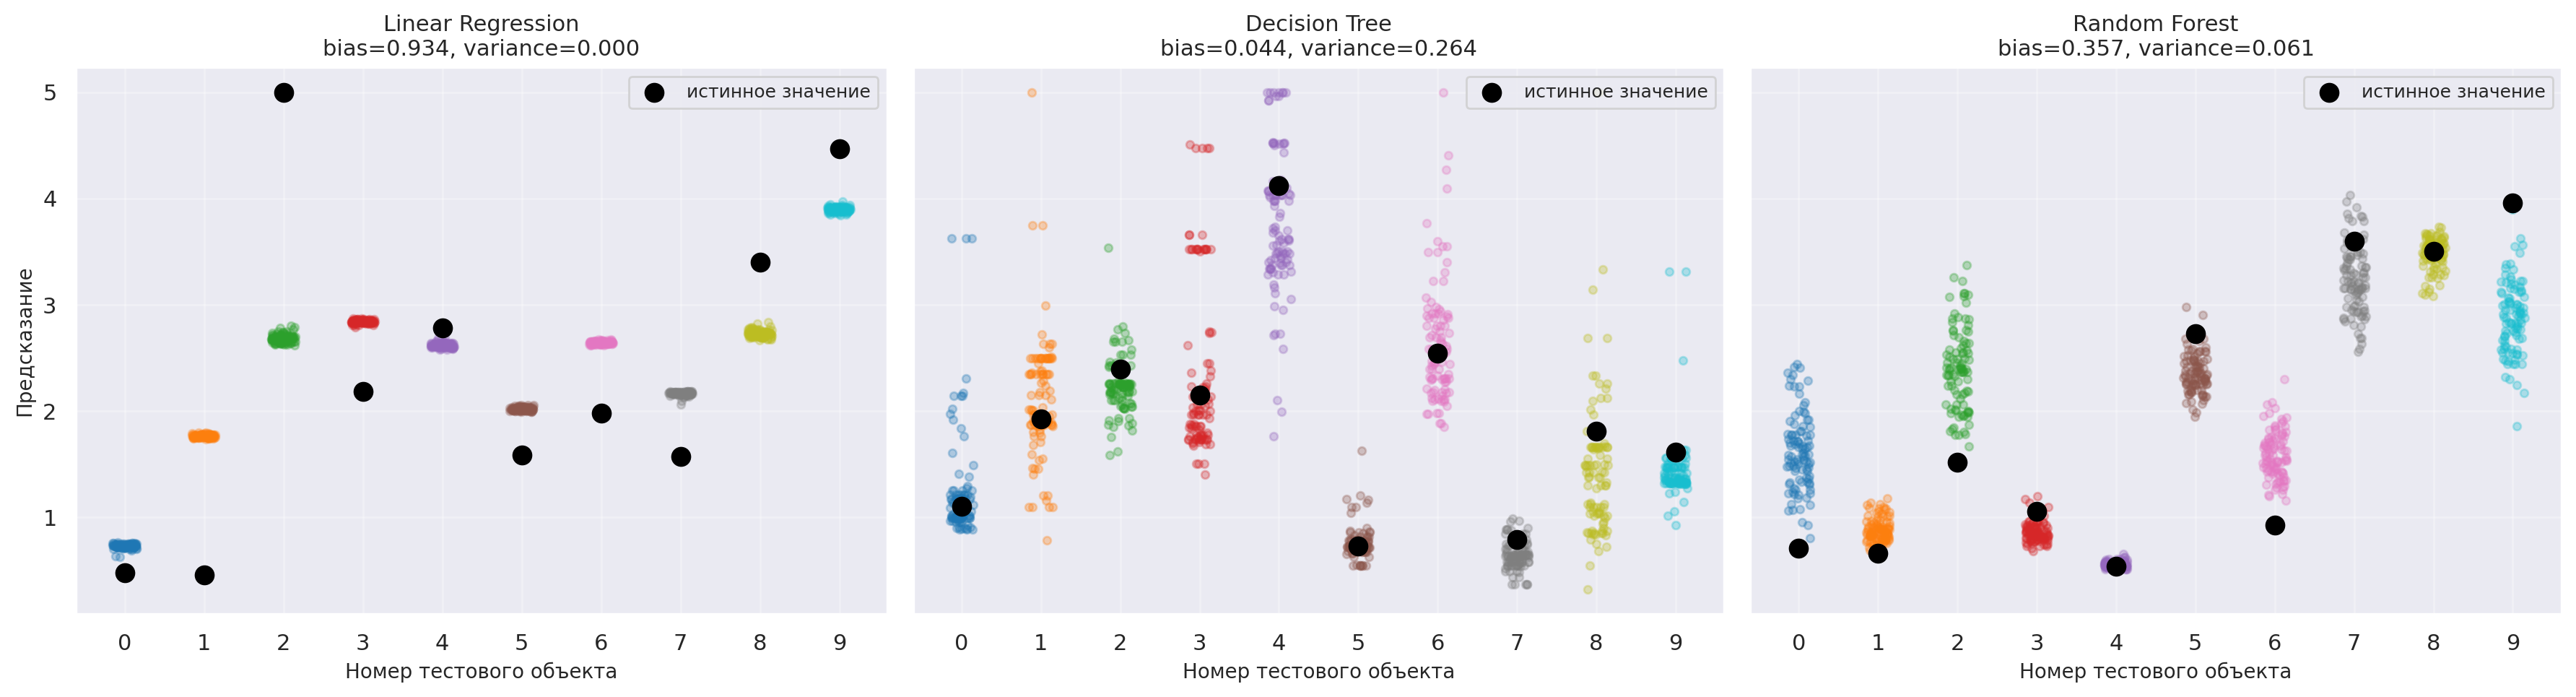

In [59]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
np.random.seed(42)
california = fetch_california_housing()
X, y = california["data"], california["target"]
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=10),
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title=name, ax=ax)
axes[1].set_ylabel("")
axes[2].set_ylabel("")
plt.tight_layout()
plt.show()

**Ответ:**\
`Linear Regression` (bias=0.934, variance=0.000)\
Столбики точек практически сливаются в одну точку. Это означает что все бутстрап-модели дают почти идентичные предсказания $\rightarrow$ разброс близок к нулю. Линейная регрессия стабильна: небольшие изменения обучающей выборки почти не меняют веса модели. Однако чёрные точки (истинные ответы) систематически далеко от центров столбиков $\rightarrow$ смещение высокое. Модель не может уловить нелинейные зависимости в данных $\rightarrow$ недооучение.

`Decision Tree` (bias=0.044, variance=0.264)\
Столбики длинные. Это означает, что предсказания разных бутстрап-моделей сильно разбросаны по вертикали $\rightarrow$ разброс высокий. Дерево без ограничений глубины запоминает обучающую выборку, и малейшее изменение данных кардинально меняет его структуру. Зато чёрные точки в среднем попадают в центр столбиков $\rightarrow$ смещение низкое. Дерево в среднем угадывает правильно, но нестабильно $\rightarrow$ переобучение.

`Random Forest` (bias=0.357, variance=0.061)\
Столбики разные: есть как короткие, так и длинные $\rightarrow$ разброс средний. Усреднение по множеству деревьев уменьшает нестабильность каждого отдельного дерева. Смещение получается выше чем у одного дерева, но ниже чем у линейной регрессии. По графику видно, что чёрные точки значительно ближе к центрам столбиков, чем у линейной регрессии, при этом многие столбики короче(компактнее), чем у дерева $\rightarrow$ лес находит баланс между смещением и разбросом.